<blank>

# **Prove di random forest**

## Preparazione dei dati

---

In [1]:
import numpy as np
# Segnale su cui effettuare Train e Validation
g_0_b = np.loadtxt('data/g_0_signal_b.txt')
g_1_b = np.loadtxt('data/g_1_signal_b.txt')
# Segnale su cui effettuare Test Esterno
g_0_a = np.loadtxt('data/g_0_signal_a.txt')
g_1_a = np.loadtxt('data/g_1_signal_a.txt')

Concatenazione gruppi e vettore dei label:

In [2]:
N0, N1 = g_0_b.shape[0], g_1_b.shape[0]
# concateno g_0 e g_1
signal_b = np.vstack((g_0_b, g_1_b))
signal_a = np.vstack((g_0_a, g_1_a))

# vettore delle risposte
labels = np.concatenate((np.zeros(N0), np.ones(N1))) # uguale per A e B

## Primissima prova

---

In [3]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

from sklearn.ensemble import RandomForestClassifier as RFC

In [4]:
pipe = Pipeline([
    ("scaling", MinMaxScaler()),       
    ("reduce_dim", PCA(n_components=5, random_state=42)),
    ("classify", RFC(random_state=42)) 
])

pipe.fit(signal_b, labels)
alt_accuracy = pipe.score(signal_a, labels)

print(f"L'accuracy del random forest è: {alt_accuracy:.4f}")

L'accuracy del random forest è: 0.5000


<blank>

# GridSearch

---

In [ ]:
rkf = RepeatedStratifiedKFold(n_splits=8, n_repeats=10, random_state=42)

# PCA
N_COMPONENTS_OPTIONS = [5]
# ESTIMATOR
N_ESTIMATOR_OPTIONS = [50, 100, 250, 500]
OBJ_FUNCTION_OPTIONS = ['gini', 'entropy']
MAX_FEATURES_OPTIONS = ["sqrt", "log2"]
MAX_DEPTH_OPTIONS = [None, 3, 5]
MIN_SAMPLES_LEAF_OPTIONS = [1, 2, 4]
BOOTSTRAP_OPTIONS = [False, True]


# 1. Definizione Pipeline #
pipe = Pipeline([
    # Step 1: Scaling
    ("scaling", StandardScaler()),       
    
    # Step 2: Riduzione dimensionalità (PCA)
    #("reduce_dim", PCA(random_state=42)),
    
    # Step 3: Classificatore
    ("classify", RFC(random_state=42)) 
])

# 2. Definizione griglia dei parametri #
param_grid = {
    
    # Per provare parametri specifici di uno step (PCA)
    #"reduce_dim__n_components": N_COMPONENTS_OPTIONS, 
    
    # Per provare parametri del classificatore
    "classify__n_estimators": N_ESTIMATOR_OPTIONS,
    
    # Per provare diverse objective funcions
    "classify__criterion": OBJ_FUNCTION_OPTIONS,
    
    # Diversi max features
    "classify__max_features": MAX_FEATURES_OPTIONS,
    
    "classify__max_depth": MAX_DEPTH_OPTIONS, # Ferma la crescita dell'albero oltre un certo limite
    
    "classify__min_samples_leaf": MIN_SAMPLES_LEAF_OPTIONS, # Stabilizza le foglie
    
    "classify__bootstrap": BOOTSTRAP_OPTIONS,
}

# 3. Configurazione GridSearch #
grid = GridSearchCV(
    pipe, 
    param_grid=param_grid, 
    cv=rkf,
    n_jobs=-1, # «Number of jobs to run in parallel. -1 means using all processors»
    scoring='accuracy'
)

# 4. Training e Validation (su Segnale B) #
grid.fit(signal_b, labels)

# 5. Risultati #
print(f"La miglior configurazione: {grid.best_params_}")
print(f"Fornisce accuracy in validation: {grid.best_score_:.4f}")

# 6. Test su segnale A #
accuracy_finale = grid.score(signal_a, labels)
print(f"Risultato sul set indipendente (Segnale A): {accuracy_finale:.4f}")

La miglior configurazione: {'classify__criterion': 'entropy', 'classify__max_depth': 5, 'classify__max_features': 'log2', 'classify__min_samples_leaf': 1, 'classify__n_estimators': 100}
Fornisce accuracy in validation: 0.7479
Risultato sul set indipendente (Segnale A): 0.3864


In [6]:
import pandas as pd

results_df = pd.DataFrame(grid.cv_results_)
# Ciascuna combinazione di parametri è una riga
print(f"Numero totale di configurazioni provate: {results_df.shape[0]}")

# Selezioniamo solo le colonne interessanti per pulire la vista
columns_to_show = [
    #'param_reduce_dim__n_components', 
    'param_classify__n_estimators', 
    'param_classify__criterion', 
    'param_classify__max_features', 
    'param_classify__max_depth',
    'param_classify__min_samples_leaf',
    'mean_test_score', 
    'std_test_score', 
    'rank_test_score'
]

# Ordiniamo per classifica (rank_test_score)
analysis = results_df[columns_to_show].sort_values('rank_test_score')

# Se si ha, è comodo aprire analysis in un viewer tipo Data Wrangler
analysis.head(20)

Numero totale di configurazioni provate: 144


,param_classify__n_estimators,param_classify__criterion,param_classify__max_features,param_classify__max_depth,param_classify__min_samples_leaf,mean_test_score,std_test_score,rank_test_score
133,100,entropy,log2,5,1,0.747917,0.184078,1
61,100,gini,log2,5,1,0.745833,0.193030,2
25,100,gini,sqrt,3,1,0.745417,0.177267,3
49,100,gini,sqrt,5,1,0.742083,0.187212,4
99,500,entropy,sqrt,3,1,0.737083,0.188045,5
50,250,gini,sqrt,5,1,0.735000,0.182719,6
26,250,gini,sqrt,3,1,0.735000,0.166575,6
34,250,gini,sqrt,3,4,0.734167,0.182496,8
55,500,gini,sqrt,5,2,0.732500,0.180814,9
106,250,entropy,sqrt,3,4,0.732083,0.180620,10


In [7]:
import pickle as pkl
results_df.to_pickle("results/risultati_GridSearch_rf.pkl")
with open("results/miglior_modello_rf", 'wb') as f:
        pkl.dump(grid.best_estimator_, f)

### analisi del best estimator

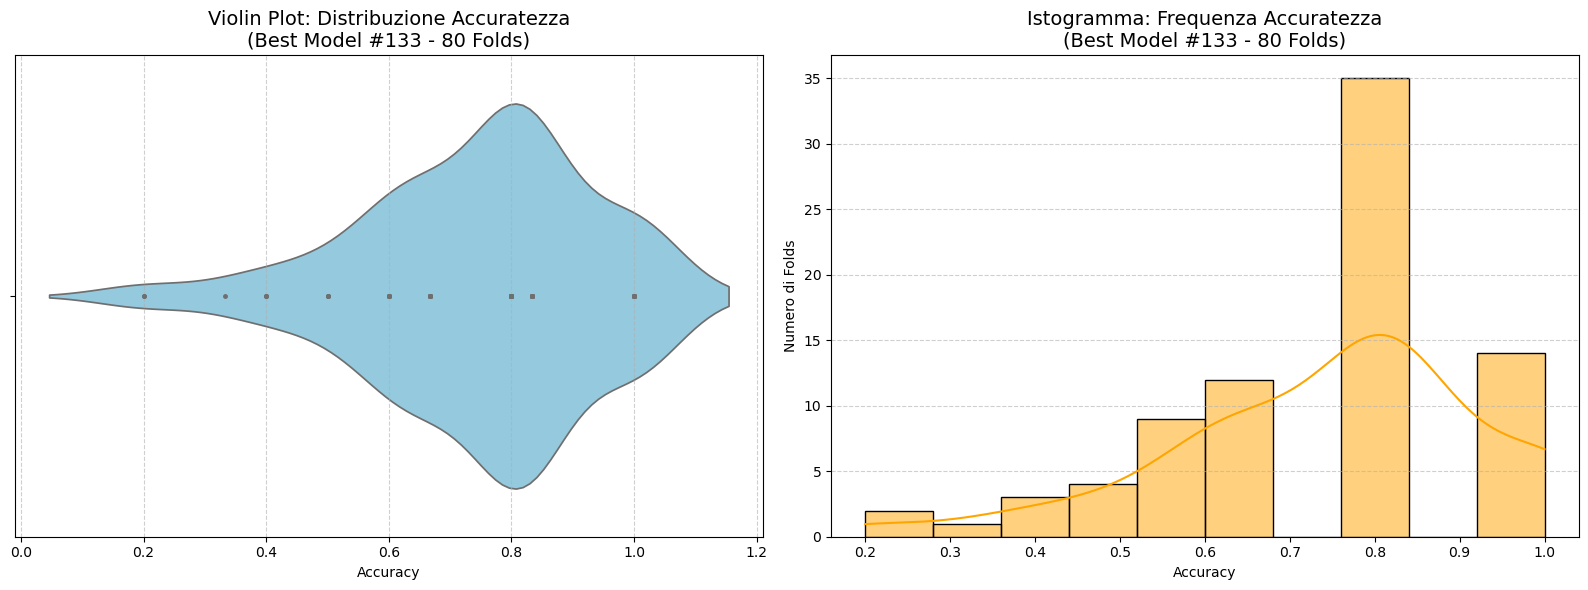

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

indice_migliore = 133

# 1. Estrazione degli 80 punteggi per il miglior modello (indice 133)
# Creiamo la lista dei nomi delle colonne da split0_test_score a split79_test_score
cols_accuracy = [f'split{i}_test_score' for i in range(80)]
best_model_scores = results_df.loc[indice_migliore, cols_accuracy].values

# 2. Creazione della figura con due subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- VIOLIN PLOT ---
# Mostra la distribuzione e la densità, con i singoli punti (folds) all'interno
sns.violinplot(x=best_model_scores, ax=axes[0], color="skyblue", inner="point")
axes[0].set_title(f'Violin Plot: Distribuzione Accuratezza\n(Best Model #{indice_migliore} - 80 Folds)', fontsize=14)
axes[0].set_xlabel('Accuracy')
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

# --- ISTOGRAMMA con KDE ---
# Mostra la frequenza dei risultati e la curva di densità stimata
sns.histplot(best_model_scores, bins=10, kde=True, ax=axes[1], color="orange")
axes[1].set_title(f'Istogramma: Frequenza Accuratezza\n(Best Model #{indice_migliore} - 80 Folds)', fontsize=14)
axes[1].set_xlabel('Accuracy')
axes[1].set_ylabel('Numero di Folds')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(f'analisi_stabilita_modello_{indice_migliore}.png')

## Majority rule?

rf con pca

grafico n_estimators vs score (fold?)

---